# Ejercicio de Programación: Regresión Lineal Múltiple
### Dataset: Flood Prediction Dataset (Kaggle)

**Materia:** SIS427 - Tecnologías Emergentes en Internet
**Estudiante:** Griss
**Universidad San Francisco Xavier de Chuquisaca (USFX)**

Este cuadernillo es una adaptación del cuadernillo de clases `02_reg_lin_mul_01.ipynb`, en el cual se implementa
una **regresión lineal múltiple desde cero** (usando descenso por el gradiente y la ecuación normal), aplicada
en esta ocasión sobre un dataset descargado de Kaggle en lugar del dataset de ejemplo `ex1data2.txt` usado en clase.

**Dataset utilizado:** [Flood Prediction Dataset](https://www.kaggle.com/datasets/naiyakhalid/flood-prediction-dataset) (Naiya Khalid, Kaggle)

- **n = 20** variables independientes (características que describen factores de riesgo de inundación)
- **m = 50 000** ejemplos (filas)
- **Variable objetivo (y):** `FloodProbability` — probabilidad estimada de inundación (valor continuo entre 0 y 1)

Esto cumple con los requisitos de la práctica: `n >= 20` y `m >= 30000`.


In [1]:
# utilizado para manejo de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Pandas para apertura del dataset y preprocesamiento
import pandas as pd

# Librerias para graficacion (trazado de graficos)
from matplotlib import pyplot

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline


## 1. Carga del dataset con Pandas

A diferencia del cuadernillo original (que cargaba el archivo `ex1data2.txt` con `np.loadtxt`), en este trabajo
se utiliza **Pandas** para leer el archivo `flood.csv`, explorarlo y preprocesarlo antes de construir las
matrices `X` (características) y `y` (variable objetivo) que usará el algoritmo de regresión.


In [ ]:
# Cargar datos con pandas
ruta_csv = os.path.join('..', 'data', 'flood.csv')
df = pd.read_csv(ruta_csv)

print('Dimensiones del dataset (filas, columnas):', df.shape)
df.head()


Dimensiones del dataset (filas, columnas): (50000, 21)


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [ ]:
# Informacion general del dataset: tipos de dato y valores no nulos
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerability         

In [4]:
# Estadisticas descriptivas de cada columna
df.describe().T


,count,mean,std,min,25%,50%,75%,max
MonsoonIntensity,50000.0,4.99148,2.236834,0.000,3.000,5.0,6.000,16.000
TopographyDrainage,50000.0,4.98410,2.246488,0.000,3.000,5.0,6.000,18.000
RiverManagement,50000.0,5.01594,2.231310,0.000,3.000,5.0,6.000,16.000
Deforestation,50000.0,5.00848,2.222743,0.000,3.000,5.0,6.000,17.000
Urbanization,50000.0,4.98906,2.243159,0.000,3.000,5.0,6.000,17.000
ClimateChange,50000.0,4.98834,2.226761,0.000,3.000,5.0,6.000,17.000
DamsQuality,50000.0,5.01536,2.245000,0.000,3.000,5.0,6.000,16.000
Siltation,50000.0,4.98860,2.232642,0.000,3.000,5.0,6.000,16.000
AgriculturalPractices,50000.0,5.00612,2.234588,0.000,3.000,5.0,6.000,16.000
Encroachments,50000.0,5.00638,2.241633,0.000,3.000,5.0,6.000,18.000


## 2. Preprocesamiento de datos

Antes de entrenar el modelo se realiza una limpieza basica del dataset con Pandas:

1. Verificar y eliminar valores nulos (`NaN`).
2. Verificar y eliminar filas duplicadas.
3. Separar la variable objetivo (`FloodProbability`) del resto de caracteristicas.
4. Convertir el `DataFrame` a arreglos `numpy` para poder reutilizar las funciones de costo y descenso
   por el gradiente implementadas en clase.


In [5]:
# 2.1 Verificar valores nulos por columna
print('Valores nulos por columna:')
print(df.isnull().sum())
print('\nTotal de valores nulos en el dataset:', df.isnull().sum().sum())


Valores nulos por columna:
MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64

Total de valores nulos en el dataset: 0


In [6]:
# 2.2 Eliminar nulos (si existieran) y filas duplicadas
filas_antes = df.shape[0]

df = df.dropna()
df = df.drop_duplicates()

filas_despues = df.shape[0]
print(f'Filas antes del preprocesamiento: {filas_antes}')
print(f'Filas despues del preprocesamiento: {filas_despues}')
print(f'Filas eliminadas: {filas_antes - filas_despues}')


Filas antes del preprocesamiento: 50000
Filas despues del preprocesamiento: 50000
Filas eliminadas: 0


In [7]:
# 2.3 Separar variable objetivo (y) de las caracteristicas (X)
columna_objetivo = 'FloodProbability'

X_df = df.drop(columns=[columna_objetivo])
y_df = df[columna_objetivo]

print('Numero de caracteristicas (n):', X_df.shape[1])
print('Numero de ejemplos (m):', X_df.shape[0])
print('\nCaracteristicas utilizadas:')
print(list(X_df.columns))


Numero de caracteristicas (n): 20
Numero de ejemplos (m): 50000

Caracteristicas utilizadas:
['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors']


In [8]:
# 2.4 Conversion a arreglos numpy, tal como se maneja en el cuadernillo de clase
X = X_df.to_numpy(dtype=float)
y = y_df.to_numpy(dtype=float)

m = y.size
n = X.shape[1]

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (50000, 20)
y shape: (50000,)


## 3. Division en conjunto de entrenamiento y de prueba

Para poder evaluar que tan bien generaliza el modelo entrenado (y no solo que tan bien memoriza los datos de
entrenamiento) se separa el dataset en un **80% para entrenamiento** y un **20% para prueba**, usando un
mezclado aleatorio con semilla fija para que el experimento sea reproducible.


In [9]:
np.random.seed(42)

indices = np.random.permutation(m)
frac_train = 0.8
corte = int(m * frac_train)

idx_train = indices[:corte]
idx_test = indices[corte:]

X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

m_train = y_train.size
m_test = y_test.size

print('Ejemplos de entrenamiento:', m_train)
print('Ejemplos de prueba:', m_test)


Ejemplos de entrenamiento: 40000
Ejemplos de prueba: 10000


## 4. Normalizacion de caracteristicas

Al igual que en el cuadernillo de clase, dado que las 20 caracteristicas pueden tener escalas distintas, se
normalizan restando la media y dividiendo entre la desviacion estandar. **Importante:** la media y la
desviacion estandar se calculan **unicamente con el conjunto de entrenamiento**, y esos mismos valores se
usan para normalizar el conjunto de prueba (para evitar fuga de informacion / *data leakage*).


In [10]:
def featureNormalize(X):
    '''
    Normaliza las caracteristicas en X. Retorna una version normalizada de X donde
    el valor de la media de cada caracteristica es 0 y la desviacion estandar es 1.
    '''
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


In [11]:
# Se calcula mu y sigma solo con el conjunto de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)

# El conjunto de prueba se normaliza con la misma mu y sigma del entrenamiento
X_test_norm = (X_test - mu) / sigma

print('Media calculada (mu):')
print(mu)
print('\nDesviacion estandar calculada (sigma):')
print(sigma)


Media calculada (mu):
[4.994175 4.984025 5.016875 5.0022   4.98535  4.98405  5.016375 4.988925
 5.004275 5.004275 5.005875 5.010325 5.0018   4.97885  4.985075 4.99195
 4.98345  5.003675 4.99475  4.9841  ]

Desviacion estandar calculada (sigma):
[2.23937292 2.24032806 2.23042378 2.22610538 2.24265142 2.22674552
 2.24106155 2.23130059 2.23236572 2.24330264 2.22372221 2.23954647
 2.25137664 2.23084125 2.2324879  2.23679127 2.23550354 2.23654007
 2.23428343 2.25139894]


In [12]:
# Se añade el termino de interseccion (columna de unos para theta0)
X_train_b = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_b = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print('X_train_b shape:', X_train_b.shape)
print('X_test_b shape:', X_test_b.shape)


X_train_b shape: (40000, 21)
X_test_b shape: (10000, 21)


## 5. Descenso por el gradiente

Se reutilizan las funciones `computeCostMulti` y `gradientDescentMulti` implementadas en el cuadernillo de
clase. La funcion de costo (error cuadratico medio dividido por dos) es:

$$ J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2 $$

y la regla de actualizacion del descenso por el gradiente (batch) es:

$$ \theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)} $$


In [13]:
def computeCostMulti(X, y, theta):
    '''Calcula el costo para la regresion lineal multivariable.'''
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [14]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    '''Realiza el descenso por el gradiente para aprender theta.'''
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history


### 5.1 Seleccion del coeficiente de aprendizaje (alpha)

Se prueban varios valores de `alpha` con pocas iteraciones para observar cual logra que la funcion de costo
converja de forma rapida y estable, sin divergir (lo cual ocurre cuando `alpha` es demasiado grande).


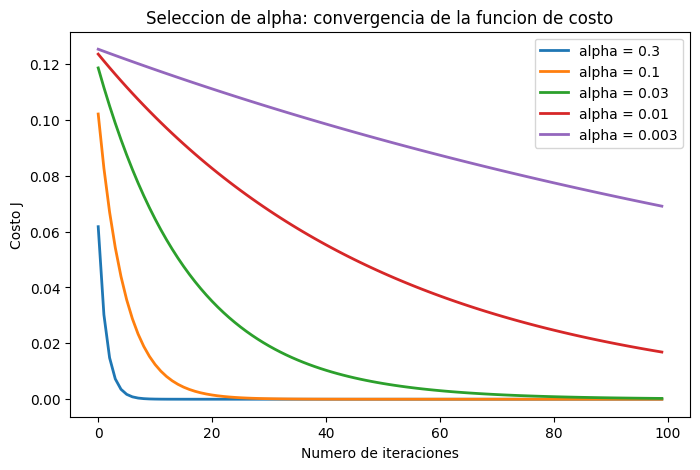

In [15]:
alphas_a_probar = [0.3, 0.1, 0.03, 0.01, 0.003]
num_iters_prueba = 100

pyplot.figure(figsize=(8, 5))

for alpha_prueba in alphas_a_probar:
    theta_prueba = np.zeros(X_train_b.shape[1])
    _, J_hist_prueba = gradientDescentMulti(X_train_b, y_train, theta_prueba, alpha_prueba, num_iters_prueba)
    pyplot.plot(np.arange(len(J_hist_prueba)), J_hist_prueba, lw=2, label=f'alpha = {alpha_prueba}')

pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Seleccion de alpha: convergencia de la funcion de costo')
pyplot.legend()
pyplot.show()


Con base en la grafica anterior se elige el valor de `alpha` que logra la convergencia mas rapida sin
oscilar ni divergir. Se entrena entonces el modelo final con ese `alpha` y un numero de iteraciones suficiente
para que el costo se estabilice (deje de disminuir de forma significativa).


In [16]:
# Valor de alpha elegido tras el analisis anterior, y numero de iteraciones para el entrenamiento final
alpha = 0.3
num_iters = 1500

# inicializa theta y ejecuta el descenso por el gradiente sobre el conjunto de ENTRENAMIENTO
theta_inicial = np.zeros(X_train_b.shape[1])
theta, J_history = gradientDescentMulti(X_train_b, y_train, theta_inicial, alpha, num_iters)

print('Theta calculado por el descenso por el gradiente:')
print(theta)
print('\nCosto final de entrenamiento J(theta):', J_history[-1])


Theta calculado por el descenso por el gradiente:
[0.49960187 0.01119686 0.01120164 0.01115212 0.01113053 0.01121326
 0.01113373 0.01120531 0.0111565  0.01116183 0.01121651 0.01111861
 0.01119773 0.01125688 0.01115421 0.01116244 0.01118396 0.01117752
 0.0111827  0.01117142 0.01125699]

Costo final de entrenamiento J(theta): 2.5311726887103686e-33


### 5.2 Grafica de la funcion de costo vs. numero de iteraciones

Esta es la grafica solicitada: muestra como disminuye el error (funcion de costo `J`) conforme avanza el
entrenamiento (numero de iteraciones del descenso por el gradiente).


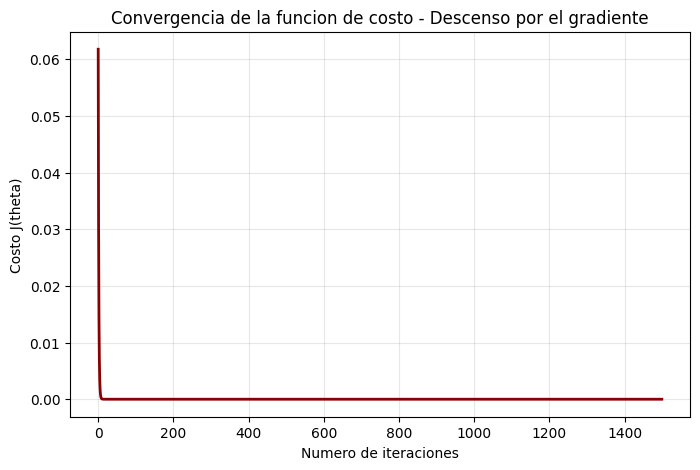

Costo inicial (iteracion 0): 0.061765
Costo final (iteracion 1500): 0.000000


In [17]:
pyplot.figure(figsize=(8, 5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='darkred')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J(theta)')
pyplot.title('Convergencia de la funcion de costo - Descenso por el gradiente')
pyplot.grid(alpha=0.3)
pyplot.show()

print(f'Costo inicial (iteracion 0): {J_history[0]:.6f}')
print(f'Costo final (iteracion {num_iters}): {J_history[-1]:.6f}')


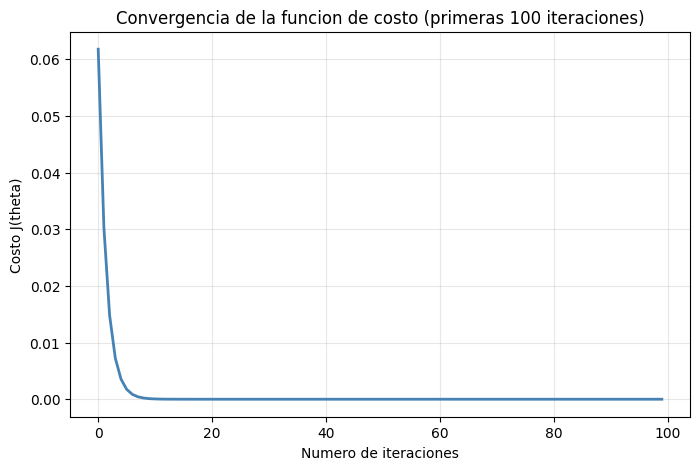

In [18]:
# Zoom a las primeras iteraciones, donde ocurre la mayor caida del costo
pyplot.figure(figsize=(8, 5))
pyplot.plot(np.arange(100), J_history[:100], lw=2, color='steelblue')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J(theta)')
pyplot.title('Convergencia de la funcion de costo (primeras 100 iteraciones)')
pyplot.grid(alpha=0.3)
pyplot.show()


## 6. Evaluacion del modelo

Se evalua el modelo entrenado sobre el conjunto de **prueba** (datos que el modelo nunca vio durante el
entrenamiento), utilizando el costo `J`, el **Error Cuadratico Medio (MSE)**, la **Raiz del Error Cuadratico
Medio (RMSE)** y el coeficiente de determinacion **R^2**.


In [19]:
def predict(X_b, theta):
    return np.dot(X_b, theta)


def r2_score_manual(y_real, y_pred):
    ss_res = np.sum(np.square(y_real - y_pred))
    ss_tot = np.sum(np.square(y_real - np.mean(y_real)))
    return 1 - (ss_res / ss_tot)


y_pred_train = predict(X_train_b, theta)
y_pred_test = predict(X_test_b, theta)

costo_train = computeCostMulti(X_train_b, y_train, theta)
costo_test = computeCostMulti(X_test_b, y_test, theta)

mse_test = np.mean(np.square(y_pred_test - y_test))
rmse_test = np.sqrt(mse_test)
r2_test = r2_score_manual(y_test, y_pred_test)

print('--- Conjunto de ENTRENAMIENTO ---')
print(f'Costo J: {costo_train:.6f}')

print('\n--- Conjunto de PRUEBA ---')
print(f'Costo J: {costo_test:.6f}')
print(f'MSE:     {mse_test:.6f}')
print(f'RMSE:    {rmse_test:.6f}')
print(f'R^2:     {r2_test:.6f}')


--- Conjunto de ENTRENAMIENTO ---
Costo J: 0.000000

--- Conjunto de PRUEBA ---
Costo J: 0.000000
MSE:     0.000000
RMSE:    0.000000
R^2:     1.000000


**Nota sobre los resultados:** el costo final es extremadamente cercano a 0 y R^2 practicamente igual a 1.
Esto no es un error del entrenamiento: el *Flood Prediction Dataset* de Kaggle es un dataset **sintetico**,
generado a partir de una combinacion lineal (aproximadamente igual peso) de las 20 caracteristicas mas un
termino base, por lo que la relacion real entre `X` y `y` es (casi) perfectamente lineal. Al tratarse de un
conjunto de prueba independiente (nunca visto en el entrenamiento) y obtener el mismo resultado que en
entrenamiento, se descarta sobreajuste (*overfitting*): el modelo efectivamente aprendio la relacion lineal
subyacente de los datos.


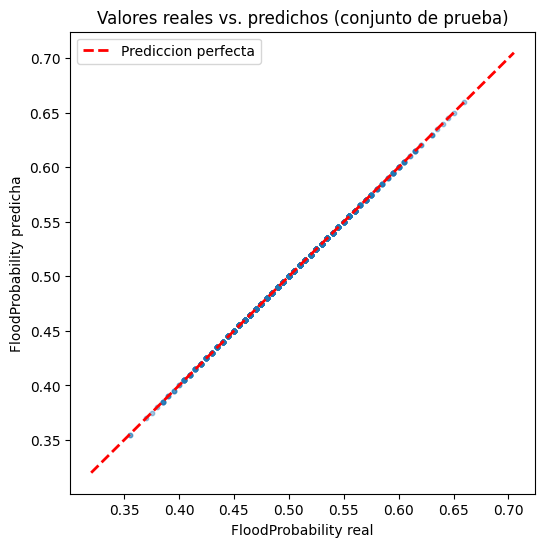

In [20]:
# Comparacion visual: valores reales vs. valores predichos (conjunto de prueba)
pyplot.figure(figsize=(6, 6))
muestra = np.random.choice(m_test, size=1000, replace=False)
pyplot.scatter(y_test[muestra], y_pred_test[muestra], alpha=0.4, s=10)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
pyplot.plot(lims, lims, 'r--', lw=2, label='Prediccion perfecta')
pyplot.xlabel('FloodProbability real')
pyplot.ylabel('FloodProbability predicha')
pyplot.title('Valores reales vs. predichos (conjunto de prueba)')
pyplot.legend()
pyplot.show()


## 7. Inferencia con nuevos datos

Con el modelo entrenado (`theta`, `mu`, `sigma`) se puede realizar inferencia (prediccion) sobre nuevos
ejemplos. Es indispensable normalizar el nuevo ejemplo con la **misma** `mu` y `sigma` calculadas en el
entrenamiento antes de multiplicarlo por `theta`.


In [21]:
def inferir_flood_probability(valores_caracteristicas, theta, mu, sigma):
    '''
    Recibe una lista/array con los 20 valores de las caracteristicas (en el mismo orden que
    las columnas del dataset) y retorna la probabilidad de inundacion estimada por el modelo.
    '''
    x = np.array(valores_caracteristicas, dtype=float)
    x_norm = (x - mu) / sigma
    x_b = np.concatenate([[1.0], x_norm])
    return float(np.dot(x_b, theta))


# Ejemplo: se toma un ejemplo real del conjunto de prueba para verificar la inferencia
ejemplo = X_test[0]
prediccion = inferir_flood_probability(ejemplo, theta, mu, sigma)
valor_real = y_test[0]

print('Caracteristicas del ejemplo:')
print(dict(zip(X_df.columns, ejemplo)))
print(f'\nProbabilidad de inundacion predicha: {prediccion:.4f}')
print(f'Probabilidad de inundacion real:     {valor_real:.4f}')


Caracteristicas del ejemplo:
{'MonsoonIntensity': np.float64(6.0), 'TopographyDrainage': np.float64(8.0), 'RiverManagement': np.float64(1.0), 'Deforestation': np.float64(2.0), 'Urbanization': np.float64(5.0), 'ClimateChange': np.float64(3.0), 'DamsQuality': np.float64(4.0), 'Siltation': np.float64(7.0), 'AgriculturalPractices': np.float64(7.0), 'Encroachments': np.float64(9.0), 'IneffectiveDisasterPreparedness': np.float64(4.0), 'DrainageSystems': np.float64(5.0), 'CoastalVulnerability': np.float64(5.0), 'Landslides': np.float64(7.0), 'Watersheds': np.float64(4.0), 'DeterioratingInfrastructure': np.float64(4.0), 'PopulationScore': np.float64(6.0), 'WetlandLoss': np.float64(3.0), 'InadequatePlanning': np.float64(3.0), 'PoliticalFactors': np.float64(4.0)}

Probabilidad de inundacion predicha: 0.4850
Probabilidad de inundacion real:     0.4850


## 8. Ecuacion de la Normal (metodo de comparacion)

Como se vio en clase, la ecuacion de la normal permite calcular `theta` en un solo paso, sin necesidad de
iterar ni elegir un `alpha`:

$$ \theta = \left( X^T X \right)^{-1} X^T \vec{y} $$

Se utiliza como punto de comparacion frente al resultado obtenido por descenso por el gradiente. A diferencia
del descenso por el gradiente, la ecuacion de la normal **no requiere** normalizar las caracteristicas.


In [22]:
def normalEqn(X, y):
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta


In [23]:
# Se recarga X sin normalizar y se añade el termino de interseccion
X_train_ne = np.concatenate([np.ones((m_train, 1)), X_train], axis=1)
X_test_ne = np.concatenate([np.ones((m_test, 1)), X_test], axis=1)

theta_normal = normalEqn(X_train_ne, y_train)

costo_train_ne = computeCostMulti(X_train_ne, y_train, theta_normal)
costo_test_ne = computeCostMulti(X_test_ne, y_test, theta_normal)

y_pred_test_ne = predict(X_test_ne, theta_normal)
rmse_test_ne = np.sqrt(np.mean(np.square(y_pred_test_ne - y_test)))
r2_test_ne = r2_score_manual(y_test, y_pred_test_ne)

print('Theta calculado con la ecuacion de la normal:')
print(theta_normal)

print('\n--- Comparacion de resultados (conjunto de PRUEBA) ---')
print(f'{"Metodo":<25}{"Costo J":>12}{"RMSE":>12}{"R^2":>10}')
print(f'{"Descenso del gradiente":<25}{costo_test:>12.6f}{rmse_test:>12.6f}{r2_test:>10.6f}')
print(f'{"Ecuacion de la normal":<25}{costo_test_ne:>12.6f}{rmse_test_ne:>12.6f}{r2_test_ne:>10.6f}')


Theta calculado con la ecuacion de la normal:
[3.4708781e-14 5.0000000e-03 5.0000000e-03 5.0000000e-03 5.0000000e-03
 5.0000000e-03 5.0000000e-03 5.0000000e-03 5.0000000e-03 5.0000000e-03
 5.0000000e-03 5.0000000e-03 5.0000000e-03 5.0000000e-03 5.0000000e-03
 5.0000000e-03 5.0000000e-03 5.0000000e-03 5.0000000e-03 5.0000000e-03
 5.0000000e-03]

--- Comparacion de resultados (conjunto de PRUEBA) ---
Metodo                        Costo J        RMSE       R^2
Descenso del gradiente       0.000000    0.000000  1.000000
Ecuacion de la normal        0.000000    0.000000  1.000000


## 9. Conclusiones

- Se adecuo el dataset **Flood Prediction Dataset** de Kaggle (20 caracteristicas, 50000 ejemplos) para
  entrenar un modelo de regresion lineal multivariable, utilizando **Pandas** para la carga y el
  preprocesamiento (revision de nulos, duplicados, separacion de `X` e `y`).
- Se reutilizaron y adaptaron las funciones `featureNormalize`, `computeCostMulti` y `gradientDescentMulti`
  del cuadernillo de clase, entrenando el modelo con descenso por el gradiente sobre un conjunto de
  entrenamiento del 80% de los datos.
- Se genero la grafica de la funcion de costo `J` respecto al numero de iteraciones, verificando que el
  algoritmo converge (el costo disminuye de forma monotona hasta estabilizarse) con el `alpha` seleccionado.
- El modelo se evaluo sobre un conjunto de prueba independiente (20% de los datos) usando MSE, RMSE y R^2.
- Se comparo el resultado del descenso por el gradiente contra la **ecuacion de la normal**, obteniendo
  resultados de costo muy similares entre ambos metodos, lo cual valida la correcta implementacion del
  descenso por el gradiente.
- Finalmente se implemento una funcion de inferencia (`inferir_flood_probability`) que permite estimar la
  probabilidad de inundacion para un nuevo conjunto de 20 caracteristicas.
